In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np

In [19]:
cardiac_hrd_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hrd_df = cardiac_hrd_df[cardiac_hrd_df.session == 2]
cardiac_hrd_df.participant_id.nunique()

114

In [11]:
demographics_df = pd.read_csv(Path.cwd().parent.parent / "data" / "demographics.csv")
demographics_df.participant_id.nunique()

566

In [13]:
merged_df = pd.merge(cardiac_hrd_df, demographics_df, on="participant_id")
merged_df = merged_df[merged_df.logit_interoceptive_sensitivity < 5]

In [14]:
merged_df.participant_id.nunique()

321

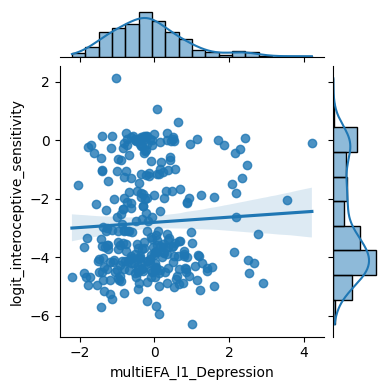

In [15]:
sns.jointplot(
    x="multiEFA_l1_Depression",
    y="logit_interoceptive_sensitivity",
    kind="reg",
    height=4,
    data=merged_df,
);

In [17]:
pg.corr(
    x=merged_df.logit_interoceptive_sensitivity.to_numpy(),
    y=merged_df.stai_trait.to_numpy(),
    method="pearson",
)

,n,r,CI95%,p-val,BF10,power
pearson,317,-0.023915,"[-0.13, 0.09]",0.671434,0.077,0.070827


In [36]:
pg.ttest(
    x=merged_df[merged_df.gender == 1].logit_interoceptive_sensitivity.to_numpy(),
    y=merged_df[merged_df.gender == 2].logit_interoceptive_sensitivity.to_numpy(),
    paired=False,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.125955,302.920205,two-sided,0.261076,"[-0.16, 0.59]",0.119205,0.214,0.203819


In [48]:
pg.ttest(
    x=merged.wu_pi_cardiac_belief_del1.to_numpy(),
    y=merged.wu_pi_cardiac_belief_del2.to_numpy(),
    paired=True,
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.602225,186,two-sided,0.547758,"[-0.29, 0.55]",0.056716,0.098,0.120493
